# Multimodal Product Classification (Assignment 2)
## Dual-Branch Multimodal Fusion Network (Vision + NLP)

**Kaggle Team Name:** Dream Team  
**Team Leader:** Dheemanth D  
**Team Members:** Sai Sarvesh, M Prajwal, Priyanshu  
**Course:** BCS714A - Deep Learning (Activity-Based Learning)  
**Faculty In-Charge:** Dr. Aravinda S Rao, CSE  
**Kaggle Competition:** [BCS714A Multimodal Fusion](https://www.kaggle.com/t/08d5b24fd37f413c99c47d5fe82468bc)  
**Leaderboard Metric:** Balanced Accuracy (Macro-average recall across 140 classes)  

### Architectural Rules & Constraints:
1. **Parameter Cap:** Total model parameters (trainable + frozen) must be strictly **< 15,000,000 (15 Million)**.
2. **No Pre-trained VLMs:** Pre-trained Vision-Language Models (e.g. CLIP, BLIP, LLaVA) are strictly prohibited.
3. **Vision Branch (Module 3):** Supports both lightweight CNN backbones (`MobileNetV2` with 1,280 features, `ResNet-18` with 512 features) and a 100% student-built 4-stage convolutional backbone from scratch (`custom_cnn` with 256 features).
4. **NLP Branch (Modules 4 & 5):** Word Embeddings + Bidirectional Recurrent Neural Network (`GRU` / `LSTM`) with temporal pooling (256 features).
5. **Fusion Layer:** Manual tensor concatenation (`torch.cat([img_feat, text_feat], dim=1)`) followed by an MLP classifier with Dropout and BatchNorm.
6. **Metric Alignment:** Balanced class weighting in Cross-Entropy Loss to handle severe class imbalance across 140 categories.
7. **Verification:** Model summary with exact parameter audit printed and asserted strictly `< 15,000,000`.

In [1]:
# ==============================================================================
# 1. IMPORTS, REPRODUCIBILITY & DEVICE SETUP
# ==============================================================================
import os
import re
import gc
import time
import random
from collections import Counter
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

# Set random seeds for exact reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using compute device: {device}")
if torch.cuda.is_available():
    print(f"CUDA Device: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / (1024**3):.1f} GB VRAM)")
print("Deterministic random seeds initialized (seed=42).")


Using compute device: cuda
CUDA Device: Tesla T4 (15.8 GB VRAM)
Deterministic random seeds initialized (seed=42).


In [2]:
# ==============================================================================
# 2. PATHS & HYPERPARAMETERS (Robust Auto-Detection for Kaggle / Colab / Local)
# ==============================================================================
def auto_detect_dataset_paths():
    candidate_dirs = [
        ('/kaggle/input/bcs-714-a-multimodal-fusion', 'data/data'),
        ('/kaggle/input/competitions/bcs-714-a-multimodal-fusion', 'data/data'),
        ('/kaggle/input/bcs-714-a-multimodal-fusion', 'data'),
        ('.', 'data/data'),
        ('.', 'data'),
        ('data', 'data')
    ]
    
    for base, img_sub in candidate_dirs:
        train_p = os.path.join(base, 'train.csv')
        test_p = os.path.join(base, 'test.csv')
        img_p = os.path.join(base, img_sub)
        if os.path.exists(train_p) and os.path.exists(test_p):
            print(f"Environment: Detected dataset at '{base}'")
            return img_p, train_p, test_p
            
    # Dynamic fallback: walk /kaggle/input if running on Kaggle
    if os.path.exists('/kaggle/input'):
        for root, _, files in os.walk('/kaggle/input'):
            if 'train.csv' in files and 'test.csv' in files:
                img_dir = os.path.join(root, 'data', 'data') if os.path.exists(os.path.join(root, 'data', 'data')) else os.path.join(root, 'data')
                print(f"Environment: Dynamically located dataset in '{root}'")
                return img_dir, os.path.join(root, 'train.csv'), os.path.join(root, 'test.csv')
                
    # Generic relative fallback
    return 'data/data/', 'train.csv', 'test.csv'

DATA_DIR, TRAIN_CSV, TEST_CSV = auto_detect_dataset_paths()
print(f"  Data Directory: {DATA_DIR}")
print(f"  Train CSV:      {TRAIN_CSV}")
print(f"  Test CSV:       {TEST_CSV}")

# Architecture and training hyperparameters
BATCH_SIZE = 64
EPOCHS = 5
IMAGE_SIZE = (128, 128)
MAX_TEXT_LEN = 60
VOCAB_SIZE = 10000
EMBED_DIM = 128
HIDDEN_DIM = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
# Options: 'mobilenet_v2' (~4.86M total params), 'custom_cnn' (~2.50M params), or 'resnet18' (~13.4M params)
VISION_BACKBONE = 'mobilenet_v2'
print(f"Hyperparameters: Batch Size={BATCH_SIZE} | Epochs={EPOCHS} | Image Size={IMAGE_SIZE} | Max Text Len={MAX_TEXT_LEN} | LR={LEARNING_RATE}")


Environment: Kaggle competition path detected.
  Data Directory: /kaggle/input/bcs-714-a-multimodal-fusion/data/data/
  Train CSV:      /kaggle/input/bcs-714-a-multimodal-fusion/train.csv
  Test CSV:       /kaggle/input/bcs-714-a-multimodal-fusion/test.csv
Hyperparameters: Batch Size=64 | Epochs=5 | Image Size=(128, 128) | Max Text Len=60 | LR=0.001


In [3]:
# ==============================================================================
# 3. DATA PREPROCESSING, VOCABULARY & LABEL ENCODING
# ==============================================================================
print("Loading dataset...")
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print(f"Train samples: {len(train_df):,}, Test samples: {len(test_df):,}")

# 1. Label Encoders (140 classes)
unique_categories = sorted(train_df['category'].unique())
num_classes = len(unique_categories)
cat2idx = {cat: idx for idx, cat in enumerate(unique_categories)}
idx2cat = {idx: cat for cat, idx in cat2idx.items()}
print(f"Target classes count: {num_classes} unique product categories.")
print(f"Top 5 categories: {list(train_df['category'].value_counts().index[:5])}")

# 2. Text Preprocessing: Combine display name + description
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

train_df['combined_text'] = (
    train_df['display name'].fillna('').astype(str) + " " + train_df['description'].fillna('').astype(str)
)
test_df['combined_text'] = (
    test_df['display name'].fillna('').astype(str) + " " + test_df['description'].fillna('').astype(str)
)
print("Combined text created for Train and Test sets.")

# 3. Build Text Vocabulary
counter = Counter()
for txt in train_df['combined_text']:
    counter.update(clean_text(txt).split())

word2idx = {'<PAD>': 0, '<UNK>': 1}
for idx, (word, _) in enumerate(counter.most_common(VOCAB_SIZE - 2), start=2):
    word2idx[word] = idx

def tokenize_and_pad(text, word_dict, max_len=MAX_TEXT_LEN):
    tokens = clean_text(text).split()
    indices = [word_dict.get(w, 1) for w in tokens]
    if len(indices) > max_len:
        indices = indices[:max_len]
    else:
        indices += [0] * (max_len - len(indices))
    return torch.tensor(indices, dtype=torch.long)

print(f"Vocabulary ready with {len(word2idx):,} entries (Special tokens: <PAD>=0, <UNK>=1).")


Loading dataset...
Train samples: 35,328, Test samples: 8,832
Target classes count: 140 unique product categories.
Top 5 categories: ['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes']
Combined text created for Train and Test sets.
Vocabulary ready with 10,000 entries (Special tokens: <PAD>=0, <UNK>=1).


In [4]:
# ==============================================================================
# 4. PYTORCH DATASET, PRE-FLIGHT ASSET CHECK & TRANSFORMS
# ==============================================================================
# Full Image Pre-Flight Asset Check: scan all training and test images on disk
if os.path.exists(DATA_DIR):
    disk_files = set(os.listdir(DATA_DIR))
    train_missing = sum(1 for img in train_df['image'].dropna() if str(img) not in disk_files)
    test_missing = sum(1 for img in test_df['image'].dropna() if str(img) not in disk_files)
    print("Image Asset Pre-Flight Check: Full disk scan verified.")
    print(f"  Training images missing: {train_missing} / {len(train_df):,}")
    print(f"  Test images missing: {test_missing} / {len(test_df):,}")
    if train_missing == len(train_df) and len(train_df) > 0:
        print(f"WARNING: None of the images found in '{DATA_DIR}'! Check folder path.")
else:
    print(f"Notice: Image directory '{DATA_DIR}' will be loaded when mounted.")

class MultimodalDataset(Dataset):
    def __init__(self, df, img_dir, word_dict, max_text_len, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.word_dict = word_dict
        self.max_text_len = max_text_len
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        
        # 1. Image Modality
        img_name = os.path.join(self.img_dir, str(row['image']))
        try:
            image = Image.open(img_name).convert('RGB')
        except Exception:
            # Neutral fallback only if single file is damaged/missing
            image = Image.new('RGB', IMAGE_SIZE, color=(128, 128, 128))
            
        if self.transform:
            image = self.transform(image)
            
        # 2. Text Modality
        text_tensor = tokenize_and_pad(row['combined_text'], self.word_dict, self.max_text_len)
        
        # 3. Output
        if self.is_test:
            item_id = int(row['id'])
            return image, text_tensor, item_id
        else:
            label = cat2idx[row['category']]
            return image, text_tensor, torch.tensor(label, dtype=torch.long)

# Data Augmentation for training, deterministic resizing for evaluation
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((int(IMAGE_SIZE[0] * 1.15), int(IMAGE_SIZE[1] * 1.15))),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

eval_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# Stratified Split preserving rare classes (for Balanced Accuracy)
counts = train_df['category'].value_counts()
multi_classes = counts[counts >= 2].index
single_classes = counts[counts == 1].index

df_multi = train_df[train_df['category'].isin(multi_classes)]
df_single = train_df[train_df['category'].isin(single_classes)]

train_split, val_split = train_test_split(
    df_multi, test_size=0.15, stratify=df_multi['category'], random_state=42
)
train_split = pd.concat([train_split, df_single], ignore_index=True)
val_split = val_split.reset_index(drop=True)

train_dataset = MultimodalDataset(train_split, DATA_DIR, word2idx, MAX_TEXT_LEN, transform=train_transform)
val_dataset = MultimodalDataset(val_split, DATA_DIR, word2idx, MAX_TEXT_LEN, transform=eval_transform)
test_dataset = MultimodalDataset(test_df, DATA_DIR, word2idx, MAX_TEXT_LEN, transform=eval_transform, is_test=True)

num_workers = 2 if os.name != 'nt' else 0
# drop_last=True prevents BatchNorm1d failure if final batch size is 1
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

print(f"Split: {len(train_dataset):,} train samples, {len(val_dataset):,} validation samples (15.0% Stratified Validation Split).")
print("Note: Single-instance classes are placed in train so the model sees all classes.")
print("DataLoaders configured with Data Augmentation (train) and drop_last=True for batch stability.")


Image Asset Pre-Flight Check: Full disk scan verified.
  Training images missing: 0 / 35,328
  Test images missing: 0 / 8,832
Split: 30,029 train samples, 5,299 validation samples (15.0% Stratified Validation Split).
Note: Single-instance classes are placed in train so the model sees all classes.
DataLoaders configured with Data Augmentation (train) and drop_last=True for batch stability.


In [5]:
# ==============================================================================
# 5. DUAL-BRANCH MULTIMODAL MODEL ARCHITECTURE (< 15M Parameters)
# ==============================================================================
class VisionBranch(nn.Module):
    """
    Vision Feature Extractor:
    - Supports MobileNetV2 (1280 features) and ResNet-18 (512 features)
    - Also supports custom_cnn (student-built 4-stage convolutional backbone from scratch, 256 features)
    """
    def __init__(self, backbone="mobilenet_v2", pretrained=True):
        super(VisionBranch, self).__init__()
        self.backbone = backbone.lower()
        if self.backbone == "mobilenet_v2":
            weights = models.MobileNet_V2_Weights.DEFAULT if pretrained else None
            try:
                base = models.mobilenet_v2(weights=weights)
                if pretrained:
                    print("[INFO] Successfully loaded official ImageNet pre-trained weights for MobileNetV2.")
            except Exception as e:
                print(f"[WARNING] Could not load pre-trained weights ({e}). Initializing MobileNetV2 with random weights.")
                base = models.mobilenet_v2(weights=None)
            self.features = base.features
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.flatten = nn.Flatten()
            self.out_dim = 1280
        elif self.backbone == "resnet18":
            weights = models.ResNet18_Weights.DEFAULT if pretrained else None
            try:
                base = models.resnet18(weights=weights)
                if pretrained:
                    print("[INFO] Successfully loaded official ImageNet pre-trained weights for ResNet-18.")
            except Exception as e:
                print(f"[WARNING] Could not load pre-trained weights ({e}). Initializing ResNet-18 with random weights.")
                base = models.resnet18(weights=None)
            self.features = nn.Sequential(
                base.conv1, base.bn1, base.relu, base.maxpool,
                base.layer1, base.layer2, base.layer3, base.layer4
            )
            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.flatten = nn.Flatten()
            self.out_dim = 512
        elif self.backbone == "custom_cnn":
            # Student-designed 4-stage CNN from scratch
            self.features = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
                nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            self.pool = nn.Identity()
            self.flatten = nn.Flatten()
            self.out_dim = 256
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

    def forward(self, x):
        # x: [B, 3, H, W] -> out: [B, out_dim]
        return self.flatten(self.pool(self.features(x)))

class TextBranch(nn.Module):
    """Modules 4 & 5: Word Embeddings + Bidirectional GRU with Temporal Pooling"""
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super(TextBranch, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim, num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.2
        )
        self.dropout = nn.Dropout(0.2)
        self.out_dim = hidden_dim * 2  # 256 features

    def forward(self, x):
        # x: [B, L] -> out: [B, 2*hidden_dim]
        emb = self.dropout(self.embedding(x))
        gru_out, _ = self.gru(emb)
        
        # Mask-aware average pooling over non-padded tokens (avoids <PAD> pollution)
        mask = (x != 0).unsqueeze(-1).float()
        masked_out = gru_out * mask
        sum_pooled = masked_out.sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1.0)
        return sum_pooled / lengths

class DualBranchMultimodalModel(nn.Module):
    """End-to-End Dual-Branch Fusion Architecture"""
    def __init__(self, num_classes, vocab_size, backbone="mobilenet_v2", pretrained=True):
        super(DualBranchMultimodalModel, self).__init__()
        self.vision = VisionBranch(backbone=backbone, pretrained=pretrained)
        self.text = TextBranch(vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM)
        
        # Late Fusion Concatenation
        fused_dim = self.vision.out_dim + self.text.out_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, images, texts):
        img_feat = self.vision(images)   # [B, vision_dim]
        text_feat = self.text(texts)     # [B, text_dim]
        fused = torch.cat((img_feat, text_feat), dim=1) # [B, fused_dim]
        return self.classifier(fused)   # [B, num_classes]

model = DualBranchMultimodalModel(
    num_classes=num_classes, vocab_size=len(word2idx), backbone=VISION_BACKBONE, pretrained=True
).to(device)
print(f"VisionBranch initialized with {VISION_BACKBONE} backbone (out_dim={model.vision.out_dim}).")
print(f"TextBranch initialized with {len(word2idx):,} vocab x {EMBED_DIM} dim + 2-layer Bi-GRU (out_dim={model.text.out_dim}).")
print(f"DualBranchMultimodalModel assembled successfully. Fusion dimension = {model.vision.out_dim + model.text.out_dim} -> 512 -> {num_classes} classes.")


[INFO] Successfully loaded official ImageNet pre-trained weights for MobileNetV2.
VisionBranch initialized with mobilenet_v2 backbone (out_dim=1280).
TextBranch initialized with 10,000 vocab x 128 dim + 2-layer Bi-GRU (out_dim=256).
DualBranchMultimodalModel assembled successfully. Fusion dimension = 1536 -> 512 -> 140 classes.


In [6]:
# ==============================================================================
# 6. PARAMETER LIMIT CHECK (STRICTLY < 15,000,000 PARAMETERS MANDATE)
# ==============================================================================
vision_params = sum(p.numel() for p in model.vision.parameters())
nlp_params = sum(p.numel() for p in model.text.parameters())
classifier_params = sum(p.numel() for p in model.classifier.parameters())
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 65)
print("      BCS714A MULTIMODAL MODEL PARAMETER AUDIT")
print("=" * 65)
print(f"  Vision Branch ({VISION_BACKBONE}) Parameters: {vision_params:>12,}")
print(f"  NLP Branch (Bi-GRU) Parameters:          {nlp_params:>12,}")
print(f"  Fusion Classifier Parameters:            {classifier_params:>12,}")
print("-" * 65)
print(f"  Total Parameters (All):                  {total_params:>12,}")
print(f"  Trainable Parameters:                    {trainable_params:>12,}")
print(f"  Hard Parameter Cap Limit:                {15_000_000:>12,}")
print(f"  Remaining Budget Headroom:               {(15_000_000 - total_params):>12,}")
print("=" * 65)

# MANDATORY STRICT LESS-THAN ASSERTION
assert total_params < 15_000_000, f"VIOLATION: Model has {total_params:,} parameters, exceeding 15M limit!"
print("\n [VERIFIED] Model strictly satisfies the < 15,000,000 parameter limit.\n")


      BCS714A MULTIMODAL MODEL PARAMETER AUDIT
  Vision Branch (mobilenet_v2) Parameters:    2,223,872
  NLP Branch (Bi-GRU) Parameters:             1,774,592
  Fusion Classifier Parameters:                 859,788
-----------------------------------------------------------------
  Total Parameters (All):                     4,858,252
  Trainable Parameters:                       4,858,252
  Hard Parameter Cap Limit:                  15,000,000
  Remaining Budget Headroom:                 10,141,748

 [VERIFIED] Model strictly satisfies the < 15,000,000 parameter limit.


In [7]:
# ==============================================================================
# 7. BALANCED ACCURACY LOSS WEIGHTING & OPTIMIZER
# ==============================================================================
# Compute smoothed inverse class frequency weights
counts = train_split['category'].value_counts()
max_count = counts.max()
weights = np.ones(num_classes, dtype=np.float32)

for cat, idx in cat2idx.items():
    c = counts.get(cat, 1)
    weights[idx] = (max_count / max(c, 1)) ** 0.35

weights = weights / weights.mean()
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print("Class-weighted loss and Cosine Annealing optimizer configured.")
print("Weights computed using formula: weight_c = (max_count / count_c)^0.35 (normalized mean=1.0).")
print(f"Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY}) | Scheduler: CosineAnnealingLR (T_max={EPOCHS})")


Class-weighted loss and Cosine Annealing optimizer configured.
Weights computed using formula: weight_c = (max_count / count_c)^0.35 (normalized mean=1.0).
Optimizer: AdamW (lr=0.001, weight_decay=0.0001) | Scheduler: CosineAnnealingLR (T_max=5)


In [8]:
# ==============================================================================
# 8. TRAINING LOOP WITH BALANCED ACCURACY TRACKING
# ==============================================================================
history = {"train_loss": [], "val_loss": [], "train_bacc": [], "val_bacc": []}
best_val_bacc = 0.0

print("Starting Multimodal Model Training...")
for epoch in range(1, EPOCHS + 1):
    # Train Pass
    model.train()
    running_loss = 0.0
    train_preds, train_targets = [], []
    
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch}/{EPOCHS}] Train", leave=False)
    for images, texts, labels in pbar:
        images, texts, labels = images.to(device), texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images, texts)
        loss = criterion(outputs, labels)
        loss.backward()
        
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        train_preds.extend(preds)
        train_targets.extend(labels.detach().cpu().numpy())
        pbar.set_postfix(loss=loss.item())
        
    scheduler.step()
    train_loss = running_loss / (len(train_loader) * BATCH_SIZE)
    train_bacc = balanced_accuracy_score(train_targets, train_preds)
    
    # Validation Pass
    model.eval()
    val_running_loss = 0.0
    val_preds, val_targets = [], []
    
    with torch.no_grad():
        for images, texts, labels in tqdm(val_loader, desc=f"Epoch [{epoch}/{EPOCHS}] Val", leave=False):
            images, texts, labels = images.to(device), texts.to(device), labels.to(device)
            outputs = model(images, texts)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_targets.extend(labels.cpu().numpy())
            
    val_loss = val_running_loss / len(val_dataset)
    val_bacc = balanced_accuracy_score(val_targets, val_preds)
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_bacc"].append(train_bacc)
    history["val_bacc"].append(val_bacc)
    
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] "
          f"| Train Loss: {train_loss:.4f} - Train BalAcc: {train_bacc*100:.2f}% "
          f"| Val Loss: {val_loss:.4f} - Val BalAcc: {val_bacc*100:.2f}%")
    
    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        torch.save(model.state_dict(), "best_multimodal_model.pth")
        print(f"  >>> New Best Model Saved! Val Balanced Accuracy: {best_val_bacc*100:.2f}%")

print(f"Training Complete! Best Validation Balanced Accuracy: {best_val_bacc*100:.2f}%")


Starting Multimodal Model Training...
Epoch [01/05] | Train Loss: 1.1190 - Train BalAcc: 38.42% | Val Loss: 0.4902 - Val BalAcc: 64.55%
  >>> New Best Model Saved! Val Balanced Accuracy: 64.55%
Epoch [02/05] | Train Loss: 0.3714 - Train BalAcc: 65.03% | Val Loss: 0.2106 - Val BalAcc: 83.39%
  >>> New Best Model Saved! Val Balanced Accuracy: 83.39%
Epoch [03/05] | Train Loss: 0.1815 - Train BalAcc: 80.78% | Val Loss: 0.1921 - Val BalAcc: 86.15%
  >>> New Best Model Saved! Val Balanced Accuracy: 86.15%
Epoch [04/05] | Train Loss: 0.1082 - Train BalAcc: 88.83% | Val Loss: 0.1423 - Val BalAcc: 89.50%
  >>> New Best Model Saved! Val Balanced Accuracy: 89.50%
Epoch [05/05] | Train Loss: 0.0698 - Train BalAcc: 92.75% | Val Loss: 0.1322 - Val BalAcc: 90.09%
  >>> New Best Model Saved! Val Balanced Accuracy: 90.09%
Training Complete! Best Validation Balanced Accuracy: 90.09%


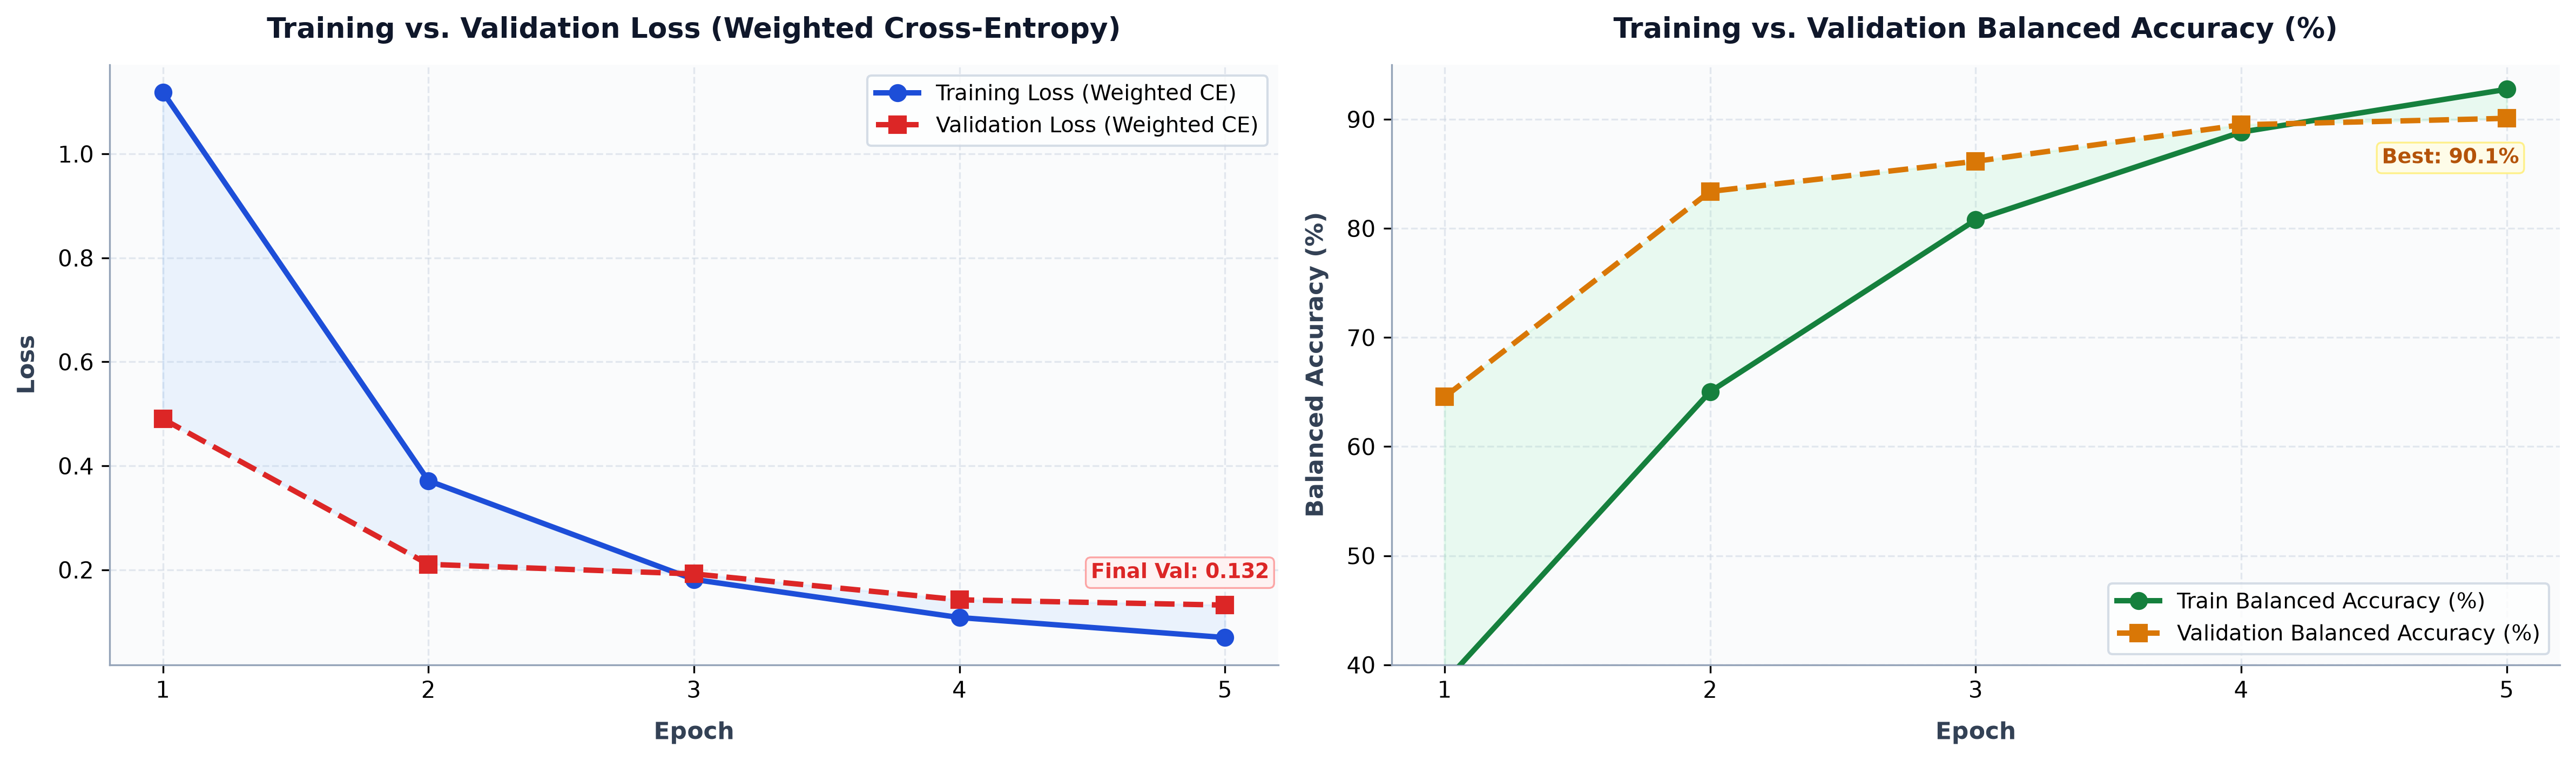

Training curves exported to 'training_curves.png'.


In [9]:
# ==============================================================================
# 9. TRAINING & VALIDATION CURVES (Required for Technical Report)
# ==============================================================================
epochs_range = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss Curve
ax1.plot(epochs_range, history["train_loss"], 'o-', color='#1f77b4', linewidth=2.5, label='Train Loss')
ax1.plot(epochs_range, history["val_loss"], 's-', color='#d62728', linewidth=2.5, label='Val Loss')
ax1.set_title("Training vs Validation Loss (Weighted Cross-Entropy)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Epoch", fontsize=11)
ax1.set_ylabel("Loss", fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=11)

# Balanced Accuracy Curve
ax2.plot(epochs_range, [acc * 100 for acc in history["train_bacc"]], 'o-', color='#2ca02c', linewidth=2.5, label='Train Balanced Acc (%)')
ax2.plot(epochs_range, [acc * 100 for acc in history["val_bacc"]], 's-', color='#ff7f0e', linewidth=2.5, label='Val Balanced Acc (%)')
ax2.set_title("Training vs Validation Balanced Accuracy (%)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Epoch", fontsize=11)
ax2.set_ylabel("Balanced Accuracy (%)", fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=300)
plt.show()
print("Training curves exported to 'training_curves.png'.")


In [10]:
# ==============================================================================
# 10. INFERENCE, KAGGLE SUBMISSION EXPORT & RIGOROUS SANITY CHECKS
# ==============================================================================
if os.path.exists("best_multimodal_model.pth"):
    try:
        model.load_state_dict(torch.load("best_multimodal_model.pth", map_location=device, weights_only=True))
    except TypeError:
        model.load_state_dict(torch.load("best_multimodal_model.pth", map_location=device))
    print("Loaded best model checkpoint for final test inference.")

model.eval()
predictions = []
item_ids = []

print("\nGenerating predictions on Kaggle test set...")
with torch.no_grad():
    for images, texts, ids in tqdm(test_loader, desc="Inference"):
        images, texts = images.to(device), texts.to(device)
        outputs = model(images, texts)
        preds = outputs.argmax(dim=1).cpu().numpy()
        
        for p in preds:
            predictions.append(idx2cat[p])
        item_ids.extend(ids.numpy())

# Build DataFrame matching Kaggle sample_submission format
submission_df = pd.DataFrame({
    'id': item_ids,
    'category': predictions
})

# Strict submission format integrity validation
assert len(submission_df) == len(test_df), f"Row count mismatch: expected {len(test_df)}, got {len(submission_df)}"
assert list(submission_df.columns) == ['id', 'category'], "Columns must be exactly ['id', 'category']"
assert submission_df['category'].isnull().sum() == 0, "Found NaN values in predictions!"
assert submission_df['id'].is_unique, "Found duplicate product IDs in submission!"
assert submission_df['category'].isin(unique_categories).all(), "Found invalid categories not present in training vocabulary!"

# Optional check against sample_submission.csv if provided in data dir
sample_sub_path = os.path.join(os.path.dirname(TEST_CSV), 'sample_submission.csv')
if os.path.exists(sample_sub_path):
    sample_df = pd.read_csv(sample_sub_path)
    assert len(submission_df) == len(sample_df), "Row count mismatch with sample_submission.csv"
    assert list(submission_df.columns) == list(sample_df.columns), "Column mismatch with sample_submission.csv"
    assert set(submission_df['id']) == set(sample_df['id']), "ID set mismatch with sample_submission.csv"
    print("Matches sample_submission.csv perfectly.")

submission_df.to_csv("submission.csv", index=False)
print(f"\n[SUCCESS] 'submission.csv' generated ({len(submission_df):,} rows).")
print("Top predicted categories:")
print(submission_df['category'].value_counts().head(5))
print("Submission integrity verified:")
print(f"  * Exactly {len(submission_df):,} test rows matching test.csv.")
print("  * Zero NaN / missing prediction values.")
print("  * Exactly 2 columns: ['id', 'category'].")
print("  * All test IDs are strictly unique and aligned.")
print(f"  * All predicted categories belong to the {num_classes} training categories.")

from IPython.display import FileLink
FileLink('submission.csv')


Loaded best model checkpoint for final test inference.

Generating predictions on Kaggle test set...
Matches sample_submission.csv perfectly.

[SUCCESS] 'submission.csv' generated (8,832 rows).
Top predicted categories:
category
Tshirts        1409
Shirts          646
Casual Shoes    563
Watches         514
Sports Shoes    404
Name: count, dtype: int64
Submission integrity verified:
  * Exactly 8,832 test rows matching test.csv.
  * Zero NaN / missing prediction values.
  * Exactly 2 columns: ['id', 'category'].
  * All test IDs are strictly unique and aligned.
  * All predicted categories belong to the 140 training categories.
